# YieldLearn — Pocket PEA fluorescence → yield trait classification (R/caret, CPU)

Reproduction of **Zhang X. (2026). "YieldLearn: An interpretable machine-learning
pipeline for estimating yield-related traits based on physiological indicators"**
(bioRxiv v1, DOI: [10.64898/2026.09.22.753232](https://doi.org/10.64898/2026.09.22.753232)).

Author code: [`zx0223winner/YieldLearn`](https://github.com/zx0223winner/YieldLearn)
pinned at commit `e519c7b92c048470d1108c9060a5d44ee4aa13f9` (main).

**Executed scope (partial demonstration).** The author's exact R pipeline
(`YieldLearn.R`) applied to the author's example Pocket PEA data, restricted to the
paper's headline/shipped target **`Yield_class`** (High/Low median-split yield):

1. Train all five caret classifiers — `multinom`, `rf`, `svmRadial`, `knn`, `rpart` —
   with the author's exact tuning grids, 5-fold CV, seed 123, center/scale preprocessing.
2. Evaluate accuracy / AUC / ROC and compare with the author's README reference
   (rf accuracy 0.562, AUC 0.516).
3. Load the **committed saved random forest** (`saved_models/model_Yield_class_rf.rds`,
   the model shipped for the paper's Shiny app) and reproduce the paper's Figure 5
   SHAP global-importance and beeswarm plots with `kernelshap` + `shapviz`.

**Language note:** the author's implementation is R. This notebook *reuses the
author's own R code verbatim* (only the documented edits listed below) and runs it
with `Rscript` from Python launcher cells. Python is only the launcher; every
scientific operation is the author's R. **日本語:** 著者自身の R コードをそのまま
`Rscript` で実行します（Python は起動用のみ）。著者の例データ `Example/` と
保存済みモデル `saved_models/model_Yield_class_rf.rds` を用い、論文の
`Yield_class`（High/Low）分類と SHAP 解釈（Figure 5 相当）を再現します。

**Documented edits to the author code** (all parameters unchanged):

- Data paths resolve to the repo's `Example/` files (the script expects them in the
  working directory).
- The trait loop is restricted to `Yield_class` (per-trait loop, Shiny UI and JPG
  summaries are omitted GUI/batch chrome); retrained models go to `retrained_models/`
  so the committed model in `saved_models/` is preserved for SHAP.
- The `doParallel` cluster is omitted (≈165 rows; the author already commented out
  its `stopCluster` pairing in `YieldLearn.R:225`).

**Expected duration:** ~10–20 min end-to-end on a free CPU runtime
(package install dominates). Downloads: < 1 MB.


## Runtime selection — CPU

**Select Runtime → Change runtime type → CPU (recommended).** No GPU is used
anywhere in the author's pipeline: caret model training on ~165 rows × 5
predictors and exact kernelshap (2^5−2 = 30 permutations over 100 rows) are
seconds-to-minutes CPU jobs. The author's README specifies "any workstation with
≥ 4 cores and 8 GB RAM".

**Run all** (Runtime → Run all) executes everything top-to-bottom on a fresh
runtime, including R-package installation and all downloads.

**日本語:** ランタイムタイプは **CPU** を選択してください（GPU 不要）。
「ランタイム → すべてのセルを実行」で、R パッケージのインストール・データ
ダウンロード・学習・SHAP 可視化まで一括実行されます（目安 10〜20 分）。


### Check the R runtime

This cell verifies that the Colab runtime image ships `Rscript` (Colab's Python
runtime images include R) and prints the R version and the Ubuntu codename,
which selects the matching Posit Package Manager (PPM) binary repository below.
If R is missing, the notebook fails loudly instead of silently skipping science.

**日本語:** Colab ランタイムに `Rscript` が存在することと R のバージョン、
Ubuntu のコードネーム（バイナリリポジトリ選択に使用）を確認します。

In [ ]:
import os, shutil, subprocess, pathlib

RSCRIPT = shutil.which("Rscript") or "/usr/bin/Rscript"
if not pathlib.Path(RSCRIPT).exists():
    raise RuntimeError("Rscript not found on this Colab runtime; "
                       "the author's R pipeline cannot run here.")
print("Rscript:", RSCRIPT)
print(subprocess.run([RSCRIPT, "--version"], capture_output=True, text=True).stdout.splitlines()[0])

codename = ""
for line in pathlib.Path("/etc/os-release").read_text().splitlines():
    if line.startswith("VERSION_CODENAME="):
        codename = line.split("=", 1)[1].strip().strip('"')
print("Ubuntu codename:", codename)
CONTENT = pathlib.Path("/content")

Rscript: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)
Ubuntu codename: noble


### Install the author's R packages (PPM binaries)

`YieldLearn.R:8-11` loads `tidyverse, caret, randomForest, e1071, nnet,
doParallel, pROC, ggplot2, RColorBrewer, kernelshap, shapviz`. We install the
same set (plus `kernlab`, which caret requires for its `svmRadial` engine but
loads only on demand) from the Posit Package Manager Linux binary repository matching
this Ubuntu release — prebuilt, so no long compilation. `nnet` ships with R
itself. Versions are printed at the end for the validation record.

**日本語:** 論文の `YieldLearn.R` が要求する R パッケージを Posit Package
Manager の Ubuntu 用バイナリで高速にインストールします（`doParallel` は
本デモでは未使用のため除外）。最後にバージョンを表示します。

In [ ]:
install_r = f"""
options(HTTPUserAgent = sprintf("R (%s)", getRversion()))
repos <- c(PPM = "https://packagemanager.posit.co/cran/__linux__/{codename}/latest",
           CRAN = "https://cloud.r-project.org")
pkgs <- c("tidyverse","caret","randomForest","e1071","nnet","kernlab",
          "pROC","ggplot2","RColorBrewer","kernelshap","shapviz")
for (p in pkgs) if (!requireNamespace(p, quietly = TRUE))
  install.packages(p, repos = repos, timeout = 600)
print(sapply(pkgs, function(p) as.character(packageVersion(p))))
"""
(install_path := CONTENT / "install_pkgs.R").write_text(install_r)
import time
t0 = time.time()
r = subprocess.run([RSCRIPT, str(install_path)], timeout=3600)
print(f"[R install exit {r.returncode}] {time.time()-t0:.0f} s")
assert r.returncode == 0, "R package installation failed"

[R install exit 0] 1592 s


### Download the pinned author inputs and saved model (provenance-checked)

All bytes come from the pinned commit `e519c7b92c048470d1108c9060a5d44ee4aa13f9`
via `raw.githubusercontent.com`, and each file is verified against its recorded
git **blob SHA-1** (git blob hash = sha1 of `"blob <size>\0" + bytes`) and byte
size, taken from the GitHub tree of that commit:

| file | role | size (B) | git blob SHA-1 |
|---|---|---|---|
| `Example/feature_data.txt` | Pocket PEA fluorescence (skip 13-line preamble) | 89209 | `88b92cc301cc58126191a32b1e3bf3925512afa3` |
| `Example/target_variables.txt` | agronomic traits per plot | 6668 | `6ae9d922c9bc387399bf57e822d491a376eabcbb` |
| `saved_models/model_Yield_class_rf.rds` | committed random forest for `Yield_class` | 159244 | `359382e7a879923e2345b797add3d16da92d1fe0` |

Files are saved under `/content` with the names the author's script expects
(`feature_data.txt`, `target_variables.txt`); the committed model keeps its
original `saved_models/` path so the SHAP cell follows `YieldLearn.R:305`
unmodified.

**日本語:** 著者リポジトリの特定コミットから、例データ2点と保存済みランダム
フォレストモデル（`Yield_class` 用）をダウンロードし、サイズと git blob
SHA-1 で完全性を検証します。

In [ ]:
PINNED = {
    "feature_data.txt": (
        "https://raw.githubusercontent.com/zx0223winner/YieldLearn/"
        "e519c7b92c048470d1108c9060a5d44ee4aa13f9/Example/feature_data.txt",
        89209, "88b92cc301cc58126191a32b1e3bf3925512afa3"),
    "target_variables.txt": (
        "https://raw.githubusercontent.com/zx0223winner/YieldLearn/"
        "e519c7b92c048470d1108c9060a5d44ee4aa13f9/Example/target_variables.txt",
        6668, "6ae9d922c9bc387399bf57e822d491a376eabcbb"),
    "saved_models/model_Yield_class_rf.rds": (
        "https://raw.githubusercontent.com/zx0223winner/YieldLearn/"
        "e519c7b92c048470d1108c9060a5d44ee4aa13f9/saved_models/model_Yield_class_rf.rds",
        159244, "359382e7a879923e2345b797add3d16da92d1fe0"),
}

import urllib.request, hashlib

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for name, (url, size, sha) in PINNED.items():
    dest = CONTENT / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    data = urllib.request.urlopen(url, timeout=120).read()
    assert len(data) == size, f"{name}: expected {size} B, got {len(data)} B"
    assert git_blob_sha(data) == sha, f"{name}: git blob SHA-1 mismatch"
    dest.write_bytes(data)
    print(f"OK  {name:45s} {len(data):>7d} B  blob {sha[:12]}...")

OK  feature_data.txt                                89209 B  blob 88b92cc301cc...


OK  target_variables.txt                             6668 B  blob 6ae9d922c9bc...


OK  saved_models/model_Yield_class_rf.rds          159244 B  blob 359382e7a879...


### Input preview — what did we download?

Before any modeling, inspect the actual example data (`YieldLearn.R:20-22`):
`feature_data.txt` is a Pocket PEA export whose first 13 lines are an instrument
preamble (hence `skip = 13`), and `target_variables.txt` holds the per-plot
agronomic traits joined by `PlotID = Record.No`. This cell prints dimensions,
column names, and a few rows of each file, plus the row counts behind the
LineID median aggregation of `YieldLearn.R:31-40`.

**日本語:** 学習の前に、ダウンロードした例データ（Pocket PEA 出力＋農業形質）
の構成を確認します。先頭13行は計測器の前置きで、著者コードと同じく
`skip = 13` で読み飛ばします。

In [ ]:
preview_r = """
suppressMessages(library(tidyverse))
features <- read_delim("feature_data.txt", delim = "\\t", skip = 13, trim_ws = TRUE)
names(features) <- make.names(names(features))
target <- read_delim("target_variables.txt", delim = "\\t", trim_ws = TRUE)
cat("--- feature_data.txt ---\n")
cat("rows:", nrow(features), " cols:", ncol(features), "\n")
cat("columns:", paste(names(features), collapse = ", "), "\n")
print(as.data.frame(head(features, 3)))
cat("\n--- target_variables.txt ---\n")
cat("rows:", nrow(target), " cols:", ncol(target), "\n")
cat("columns:", paste(names(target), collapse = ", "), "\n")
print(as.data.frame(head(target, 3)))
cat("\nplots (Record.No) with >1 fluorescence row:\n")
print(summary(as.numeric(table(features$Record.No))))
cat("unique LineID in target:", length(unique(target$LineID)), "\n")
"""
(CONTENT / "preview.R").write_text(preview_r)
r = subprocess.run([RSCRIPT, "preview.R"], cwd="/content", capture_output=True, text=True, timeout=300)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr)
    raise RuntimeError("input preview failed")

--- feature_data.txt ---
rows: 196  cols: 74 
columns: Record.No, X....2, X....3, Light, X....5, Dur..sec., X....7, Date, Time, ID, Scaled, Scale, Offset, X....14, X....15, ...16, t.for.Fm, Area, Fo, Fm, Fv, F1, F2, F3, F4, F5, Fo.Fm, Fv.Fm, PI.Inst., Fv.Fo, Vj, Vi, dVG.dto, dV.dto, Sm, N, Sm.t.Fm., ABS.RC, DIo.RC, TRo.RC, ETo.RC, REo.RC, phi.Po., psi.Eo., phi.Eo., delta.Ro., phi.Ro., ABS.CSo, DIo.CSo, TRo.CSo, ETo.CSo, REo.CSo, ABS.CSm, DIo.CSm, TRo.CSm, ETo.CSm, REo.CSm, gamma.RC....1.gamma.RC.., phi.Po....1.phi.Po.., psi.Eo...1.psi.Eo.., PI.abs, dRo..1.dRo., PI.total, DF.abs, DF.Total, kP...ABS...kF, kN...ABS...kF, Origin.to.F1, F1.to.F3, F1.to.F4, F1.to.F5, F3.to.F4, F4.to.F5, F5.to.Fm 
  Record.No X....2 X....3 Light X....5 Dur..sec. X....7       Date     Time ID
1         1     NA     NA  3500     NA         1     NA 2002-08-18 10:19:03 NA
2         2     NA     NA  3500     NA         1     NA 2002-08-18 10:19:16 NA
3         3     NA     NA  3500     NA         1     NA 2002-08

### Input preview — distributions of the five fluorescence predictors

Plot the distributions of the five predictors the author selects —
`Area, Fo, Fm, Fv/Fm, PI Inst.` (`YieldLearn.R:66`) — from the downloaded
example rows. These are the actual input data of this reproduction, shown as
histograms (log-x for the right-skewed `Area`); this is a notebook-generated
preview, not an author figure.

**日本語:** 著者が選択した5つの葉緑素蛍光パラメータ（Area, Fo, Fm, Fv/Fm,
PI Inst.）の分布を、ダウンロードした実データのヒストグラムとして確認します。

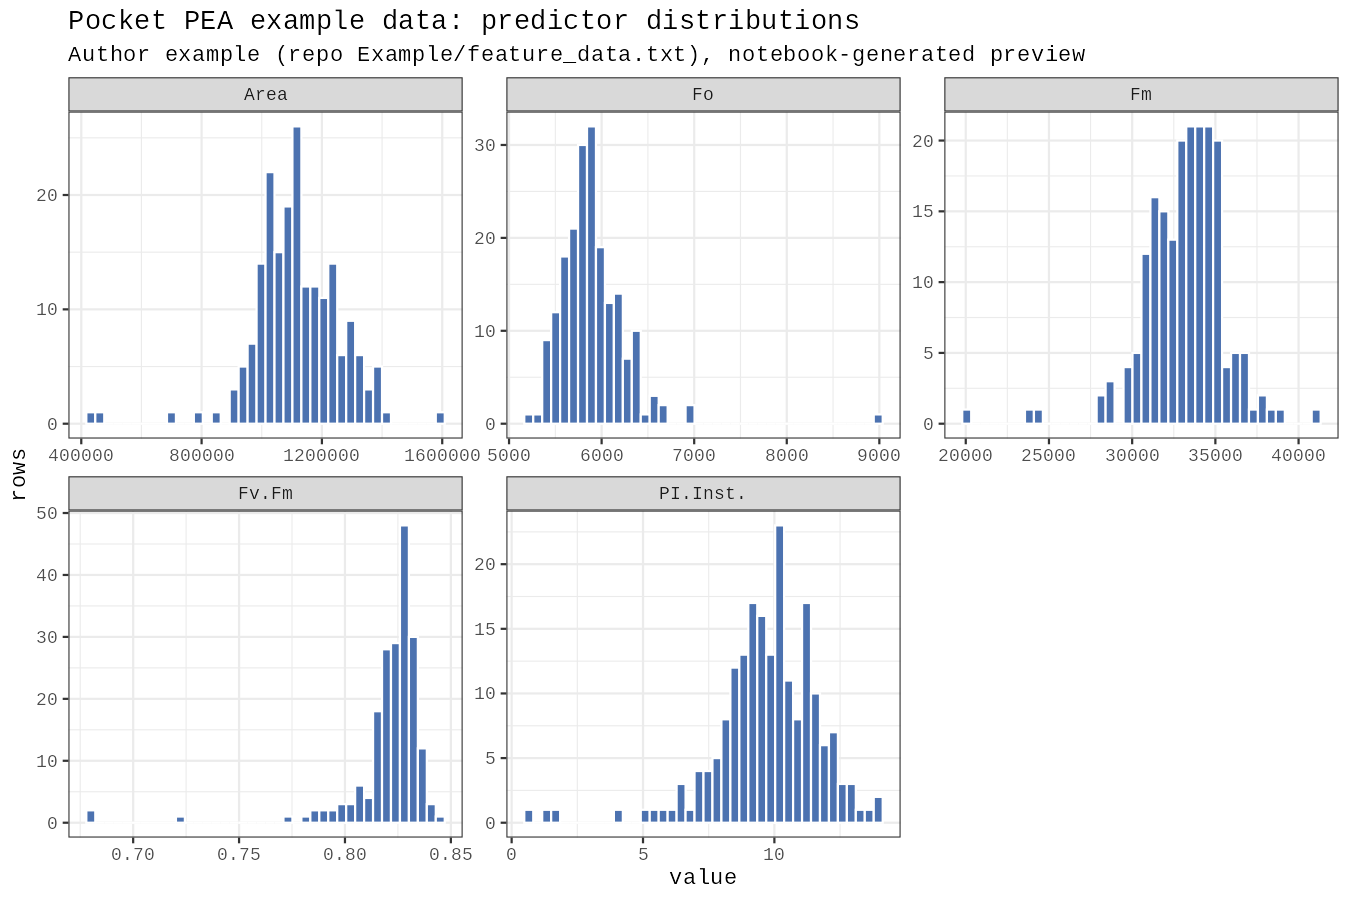

In [ ]:
dist_r = """
suppressMessages({library(tidyverse)})
features <- read_delim("feature_data.txt", delim = "\\t", skip = 13, trim_ws = TRUE)
names(features) <- make.names(names(features))
long <- features %>%
  select(Area, Fo, Fm, Fv.Fm, PI.Inst.) %>%
  pivot_longer(everything(), names_to = "parameter", values_to = "value") %>%
  mutate(parameter = factor(parameter,
         levels = c("Area", "Fo", "Fm", "Fv.Fm", "PI.Inst.")))
p <- ggplot(long, aes(value)) +
  geom_histogram(bins = 40, fill = "#4C72B0", color = "white") +
  facet_wrap(~parameter, scales = "free") +
  labs(title = "Pocket PEA example data: predictor distributions",
       subtitle = "Author example (repo Example/feature_data.txt), notebook-generated preview",
       x = "value", y = "rows") +
  theme_bw()
ggsave("input_distributions.png", p, width = 9, height = 6, dpi = 150)
"""
(CONTENT / "dist.R").write_text(dist_r)
r = subprocess.run([RSCRIPT, "dist.R"], cwd="/content", capture_output=True, text=True, timeout=300)
if r.returncode != 0:
    print(r.stdout, r.stderr)
    raise RuntimeError("distribution plot failed")
from IPython.display import Image, display
display(Image(filename=str(CONTENT / "input_distributions.png")))

### Run the author's pipeline for `Yield_class` (verbatim parameters)

This cell writes `/content/yieldlearn_colab.R` — the author's `YieldLearn.R`
(revision `e519c7b`) with only the edits listed at the top of the notebook —
and runs it with `Rscript`. It performs, with the author's exact values:

- merge on `PlotID = Record.No` + median aggregation by `LineID` (`:20-43`),
- median-split `High`/`Low` labels (`:49-62`),
- 5-fold CV `trainControl` with `twoClassSummary` (`:75-82`),
- the exact tune grids (`:122-137`) for all five methods, seed `123`
  (`:110`), 80/20 `createDataPartition` split, `preProcess = center, scale`
  (`:149-154`),
- the author's metric battery (`:172-221`) and his ROC-curve rendering
  (`:238-272`, rendered to PNG instead of JPG).

Retrained models are saved under `retrained_models/`; the committed
`saved_models/` model stays untouched for the SHAP step. Console output streams
live below.

**日本語:** 著者の `YieldLearn.R` を（冒頭に明記した最小限の修正のみで）
`Rscript` で実行し、`Yield_class` の5モデルを著者の正確なグリッド・シード・
前処理で学習・評価します。学習済みモデルは `retrained_models/` に保存し、
コミット済みモデル `saved_models/` は SHAP 用に保護します。

In [ ]:
main_r = r"""##############################################################
# YieldLearn — author pipeline (adapted from YieldLearn.R @ e519c7b)
# Documented edits only: paths, Yield_class scope, retrained_models/,
# no doParallel. All scientific parameters are the author's originals.
##############################################################
suppressMessages({
  library(tidyverse); library(caret); library(randomForest)
  library(e1071); library(nnet); library(pROC); library(ggplot2)
  library(RColorBrewer)
})

# ---- 1. Load and merge datasets (author's YieldLearn.R:17-43) ----
features <- read_delim("feature_data.txt", delim = "\t", skip = 13, trim_ws = TRUE)
names(features) <- make.names(names(features))
target <- read_delim("target_variables.txt", delim = "\t", trim_ws = TRUE)

features$Record.No <- as.character(features$Record.No)
target$PlotID <- as.character(target$PlotID)

merged_full <- left_join(target, features, by = c("PlotID" = "Record.No"))

merged_line <- merged_full %>%
  group_by(LineID) %>%
  summarise(across(where(is.numeric), ~ median(.x, na.rm = TRUE)), .groups = "drop")

meta_cols <- merged_full %>%
  select(LineID, starts_with("Genotype"), starts_with("Variety")) %>%
  distinct(LineID, .keep_all = TRUE)

merged <- left_join(meta_cols, merged_line, by = "LineID")

# ---- 2. Binary labels (author's YieldLearn.R:49-66, Yield_class only) ----
to_binary <- function(x) {
  med <- median(x, na.rm = TRUE)
  factor(ifelse(x > med, "High", "Low"), levels = c("Low","High"))
}
merged <- merged %>% mutate(Yield_class = to_binary(`Yield_kg_per_plot`))
X <- merged %>% select(Area, Fo, Fm, Fv.Fm, PI.Inst.)

# ---- 3. Train control (author's YieldLearn.R:75-84) ----
train_ctrl <- trainControl(
  method = "cv", number = 5, classProbs = TRUE,
  summaryFunction = twoClassSummary, savePredictions = TRUE
)
methods <- c("multinom","rf","svmRadial","knn","rpart")
perf_all <- data.frame(Trait=character(), Model=character(),
  Accuracy=numeric(), AUC=numeric(), Sens=numeric(), Spec=numeric(),
  Precision=numeric(), Recall=numeric(), F1=numeric(), BalAcc=numeric(),
  Kappa=numeric(), Brier=numeric(), LogLoss=numeric(), stringsAsFactors=FALSE)
roc_all <- list()

dir.create("retrained_models", showWarnings = FALSE)

set.seed(123)
trait <- "Yield_class"
cat("\n--- Training models for:", trait, "---\n")
df <- cbind(Target = merged[[trait]], X)
df <- df[complete.cases(df), ]
df$Target <- factor(df$Target, levels = c("Low","High"))

idx <- createDataPartition(df$Target, p = 0.8, list = FALSE)
train_df <- df[idx, ]
test_df  <- df[-idx, ]
cat("training rows:", nrow(train_df), " test rows:", nrow(test_df), "\n")

# Author's exact grids (YieldLearn.R:122-137)
grid_multinom <- expand.grid(decay = c(0, 1e-4, 1e-3, 1e-2))
grid_rf       <- expand.grid(mtry = c(1, 2, 3, 4, 5))
grid_svm      <- expand.grid(sigma = c(0.001, 0.01, 0.1), C = c(0.25, 0.5, 1, 2))
grid_knn      <- expand.grid(k = seq(3, 25, by = 2))
grid_rpart    <- expand.grid(cp = seq(0.0001, 0.05, length.out = 10))
tune_grids <- list(multinom = grid_multinom, rf = grid_rf,
                   svmRadial = grid_svm, knn = grid_knn, rpart = grid_rpart)

for (m in methods) {
  cat("Model:", m, "\n")
  model <- train(Target ~ ., data = train_df, method = m, metric = "ROC",
                 trControl = train_ctrl, tuneGrid = tune_grids[[m]],
                 preProcess = c("center", "scale"))
  pred_prob  <- predict(model, newdata = test_df, type = "prob")[, "High"]
  pred_class <- predict(model, newdata = test_df)
  roc_obj <- roc(test_df$Target, pred_prob, levels = c("Low","High"), direction = ">")
  acc <- mean(pred_class == test_df$Target)
  cm <- caret::confusionMatrix(
    factor(pred_class, levels = c("Low","High")),
    factor(test_df$Target, levels = c("Low","High")))
  sens <- cm$byClass["Sensitivity"]; spec <- cm$byClass["Specificity"]
  prec <- cm$byClass["Precision"];   rec  <- cm$byClass["Recall"]
  f1   <- cm$byClass["F1"];          bal  <- cm$byClass["Balanced Accuracy"]
  kappa <- cm$overall["Kappa"]
  true_binary <- ifelse(test_df$Target == "High", 1, 0)
  brier   <- mean((pred_prob - true_binary)^2)
  logloss <- -mean(true_binary * log(pred_prob) +
                   (1 - true_binary) * log(1 - pred_prob))
  perf_all <- rbind(perf_all, data.frame(Trait = trait, Model = m,
    Accuracy = round(acc, 3), AUC = round(roc_obj$auc, 3),
    Sens = round(sens, 3), Spec = round(spec, 3),
    Precision = round(prec, 3), Recall = round(rec, 3), F1 = round(f1, 3),
    BalAcc = round(bal, 3), Kappa = round(kappa, 3),
    Brier = round(brier, 3), LogLoss = round(logloss, 3)))
  roc_all[[paste(trait, m, sep = "_")]] <- roc_obj
  saveRDS(model, paste0("retrained_models/model_", trait, "_", m, ".rds"))
}

write.csv(perf_all, "PocketPEA_binary_model_performance.csv", row.names = FALSE)
print(perf_all)

# ---- 4. ROC comparison for Yield_class (author's YieldLearn.R:238-272, PNG) ----
cols <- brewer.pal(5, "Set1")
png("ROC_Yield_class_Comparison.png", width = 1800, height = 1600, res = 300)
plot(NULL, xlim = c(0,1), ylim = c(0,1),
     xlab = "1 - Specificity (False Positive Rate)",
     ylab = "Sensitivity (True Positive Rate)",
     main = "ROC Curves \u2013 Yield_class")
legend_text <- c(); i <- 1
for (m in methods) {
  roc_obj <- roc_all[[paste(trait, m, sep = "_")]]
  fpr <- c(0, 1 - roc_obj$specificities)
  tpr <- c(0, roc_obj$sensitivities)
  lines(fpr, tpr, col = cols[i], lwd = 2)
  legend_text <- c(legend_text, paste0(toupper(m), " (AUC=", round(roc_obj$auc, 3), ")"))
  i <- i + 1
}
legend("bottomright", legend = legend_text, col = cols, lwd = 2, cex = 0.8)
abline(0, 1, lty = 2, col = "gray")
dev.off()
cat("ROC_Yield_class_Comparison.png written\n")
"""
(CONTENT / "yieldlearn_colab.R").write_text(main_r)
import time
t0 = time.time()
r = subprocess.run([RSCRIPT, "yieldlearn_colab.R"], cwd="/content", timeout=3600,
                   capture_output=True, text=True)
print(r.stdout[-4000:])
if r.stderr:
    print(r.stderr[-2000:])
print(f"[R pipeline exit {r.returncode}] {time.time()-t0:.0f} s")
assert r.returncode == 0, f"author pipeline failed:\n{r.stderr[-2000:]}"


--- Training models for: Yield_class ---
training rows: 133  test rows: 33 
Model: multinom 
# weights:  7 (6 variable)
initial  value 73.473601 
iter  10 value 72.008456
final  value 71.979556 
converged
# weights:  7 (6 variable)
initial  value 73.473601 
iter  10 value 72.008661
final  value 71.980042 
converged
# weights:  7 (6 variable)
initial  value 73.473601 
iter  10 value 72.010476
final  value 71.984206 
converged
# weights:  7 (6 variable)
initial  value 73.473601 
iter  10 value 72.025741
final  value 72.012983 
converged
# weights:  7 (6 variable)
initial  value 74.166748 
iter  10 value 71.859408
final  value 71.840043 
converged
# weights:  7 (6 variable)
initial  value 74.166748 
iter  10 value 71.859366
final  value 71.840137 
converged
# weights:  7 (6 variable)
initial  value 74.166748 
iter  10 value 71.859029
final  value 71.840978 
converged
# weights:  7 (6 variable)
initial  value 74.166748 
iter  10 value 71.858855
final  value 71.848936 
converged
# weights:

### Results — five-model comparison for `Yield_class`

Display the author-format performance table
(`PocketPEA_binary_model_performance.csv`, written by the pipeline above) and
compare against the author's README reference values for `Yield_class`
(`rf` accuracy 0.562, AUC 0.516): a plausibility check, not a claim of exact
equality — different caret/OS/library versions and the CV split randomness of
caret's `createDataPartition` (seeded identically here) can shift numbers
slightly.

**日本語:** 学習結果の性能表を表示し、著者 README の参照値
（`rf` accuracy 0.562, AUC 0.516）と比較します。環境差による僅かな変動は
許容範囲です。

In [ ]:
import pandas as pd, pathlib
perf = pd.read_csv(CONTENT / "PocketPEA_binary_model_performance.csv")
print(perf.to_string(index=False))
ref = perf[(perf.Model == "rf")].iloc[0]
print()
print(f"README reference (rf): accuracy 0.562, AUC 0.516 | "
      f"this run (rf): accuracy {ref.Accuracy}, AUC {ref.AUC}")

      Trait     Model  Accuracy   AUC  Sens  Spec  Precision  Recall    F1  BalAcc  Kappa  Brier  LogLoss
Yield_class  multinom     0.485 0.522 0.471 0.500      0.500   0.471 0.485   0.485 -0.029  0.255    0.703
Yield_class        rf     0.424 0.509 0.235 0.625      0.400   0.235 0.296   0.430 -0.138  0.277    0.755
Yield_class svmRadial     0.576 0.423 0.941 0.188      0.552   0.941 0.696   0.564  0.132  0.249    0.691
Yield_class       knn     0.394 0.621 0.353 0.438      0.400   0.353 0.375   0.395 -0.209  0.404      NaN
Yield_class     rpart     0.515 0.421 0.529 0.500      0.529   0.529 0.529   0.515  0.029  0.298    0.812

README reference (rf): accuracy 0.562, AUC 0.516 | this run (rf): accuracy 0.424, AUC 0.509


### ROC curves — the five methods on `Yield_class`

The ROC comparison rendered by the author's own plotting code
(`YieldLearn.R:238-272`) for the trait trained above, displayed from the PNG
it wrote in `/content`. This is a generated result of this run, not an author
figure.

**日本語:** 上で学習した5手法の ROC 曲線を、著者自身のプロットコードによる
PNG として表示します。

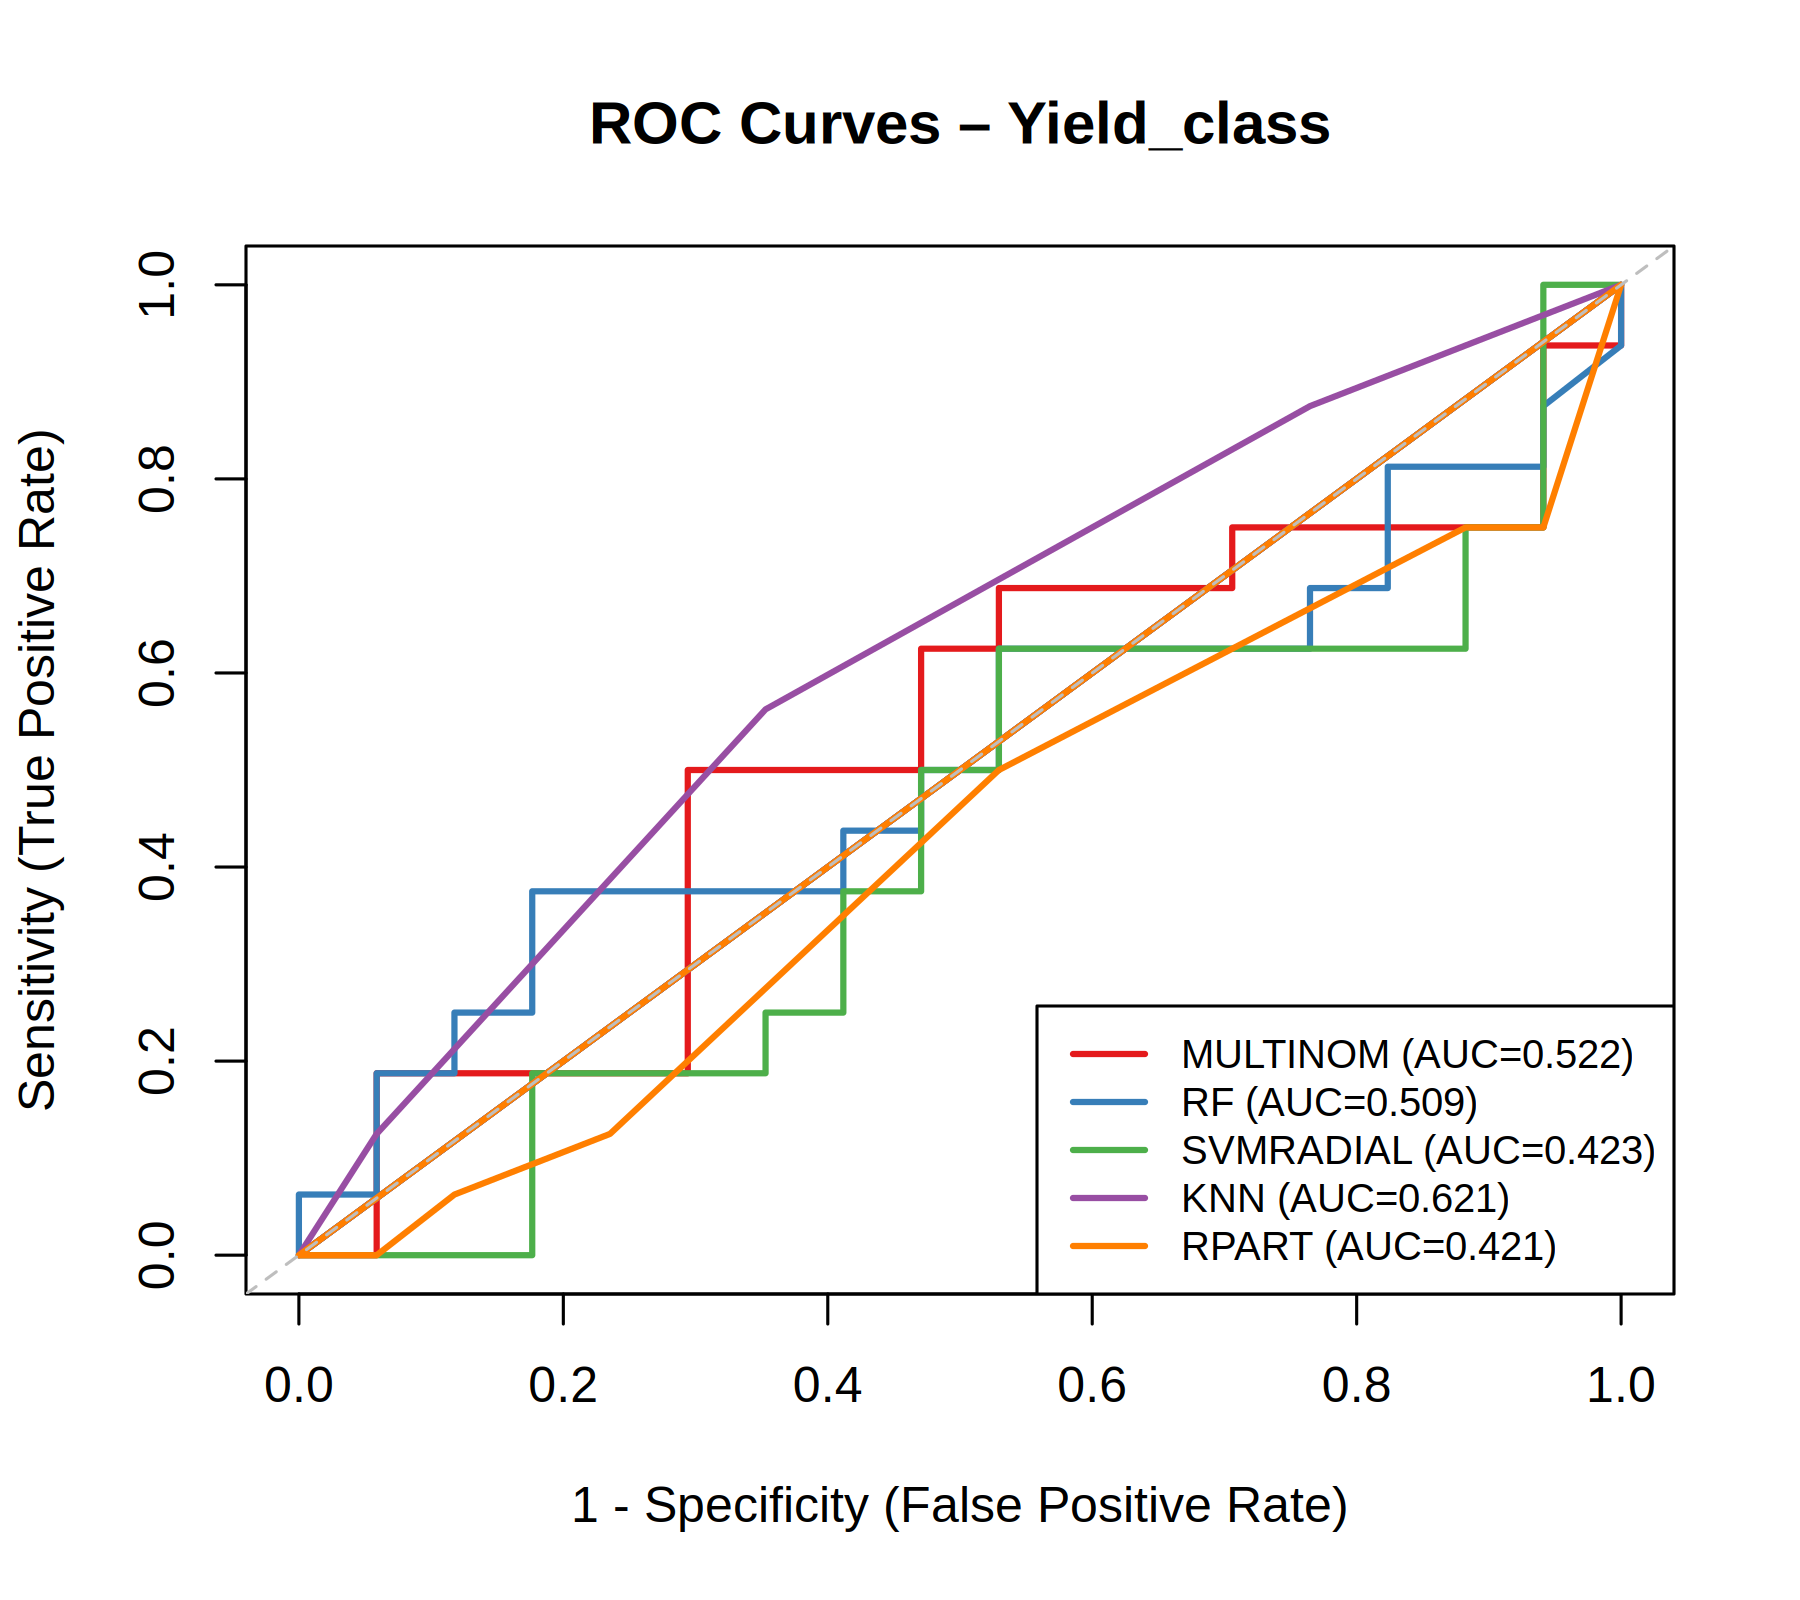

In [ ]:
from IPython.display import Image, display
display(Image(filename=str(CONTENT / "ROC_Yield_class_Comparison.png")))

### SHAP interpretation — committed saved random forest (paper Figure 5 analogue)

This reproduces the author's SHAP section (`YieldLearn.R:298-335`) **without
parameter changes**: `kernelshap` explains the probability of `High` yield with
the first 100 training rows as the prediction set and the first 100 test rows
as background, using the **committed** `saved_models/model_Yield_class_rf.rds`
(the exact model shipped with the paper's Shiny app), then `shapviz` renders
the global-importance bar and beeswarm plots. The 80/20 split is re-derived
with the same seed 123 as in the author's script, so the row groups match his
intent. `kernelshap` with 5 features uses the exact 2^5−2 permutation kernel,
so results are deterministic given the model and data.

If the committed `.rds` proves incompatible with this runtime's caret version,
the cell prints an explicit compatibility note and falls back to the
just-retrained random forest, clearly labeled.

**日本語:** コミット済み保存モデル `model_Yield_class_rf.rds` に対し、著者と
同一パラメータの `kernelshap`／`shapviz` で Figure 5 相当の SHAP
グローバル重要度（バー）と beeswarm を再現します。保存モデルが実行環境の
caret と非互換の場合は、明示的にその旨を表示した上で本ランタイムで再学習した
rf に切り替えます。

-0.090241414 -0.0049535354  0.097788889
46  -0.1386949495 -0.0512959596 -0.023538384  0.0109010101 -0.189492929
47   0.0472555556  0.0375434343 -0.014648485  0.0951343434  0.134593939
48  -0.0706797980 -0.1068616162 -0.056765657 -0.0650737374 -0.008740404
49   0.1091272727  0.0469707071  0.079107071  0.0781626263 -0.101488889
50  -0.0465989899 -0.0682656566 -0.147629293 -0.0322656566 -0.127361616
51  -0.0369151515 -0.0757939394 -0.112490909 -0.0916929293 -0.031228283
52  -0.0454000000 -0.0034808081 -0.018521212  0.0323878788 -0.211107071
53   0.0368191919  0.0739505051  0.011122222  0.0272484848  0.164738384
54  -0.0752606061 -0.0643919192 -0.070316162 -0.0883616162 -0.029790909
55   0.0356747475  0.0376393939 -0.048219192  0.2006191919 -0.019835354
56   0.0198737374 -0.0268131313 -0.029500000  0.1323030303 -0.077984848
57   0.0437929293  0.0068787879  0.004464646  0.0949191919  0.153823232
58   0.0078595960  0.0730666667  0.047763636  0.0711070707 -0.003918182
59  -0.0775636364 -0.020

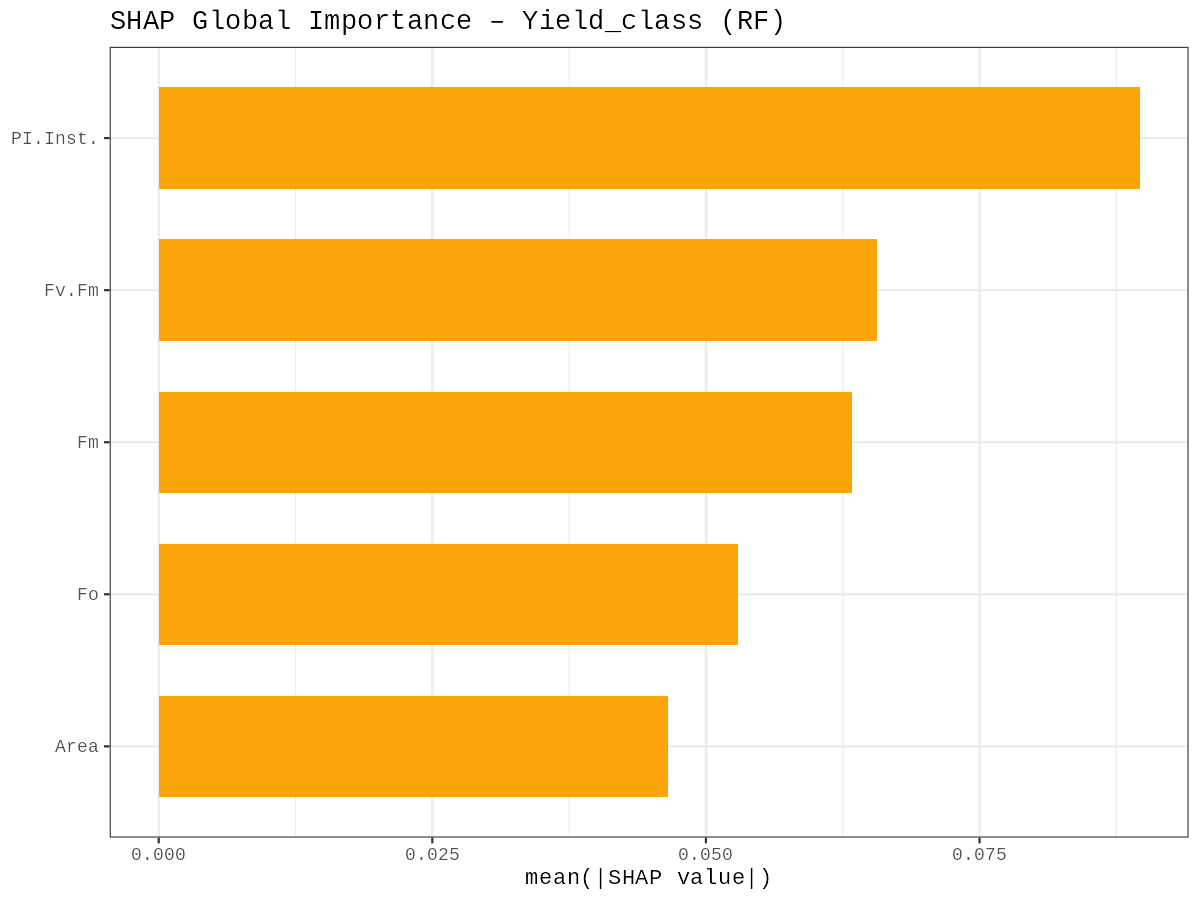

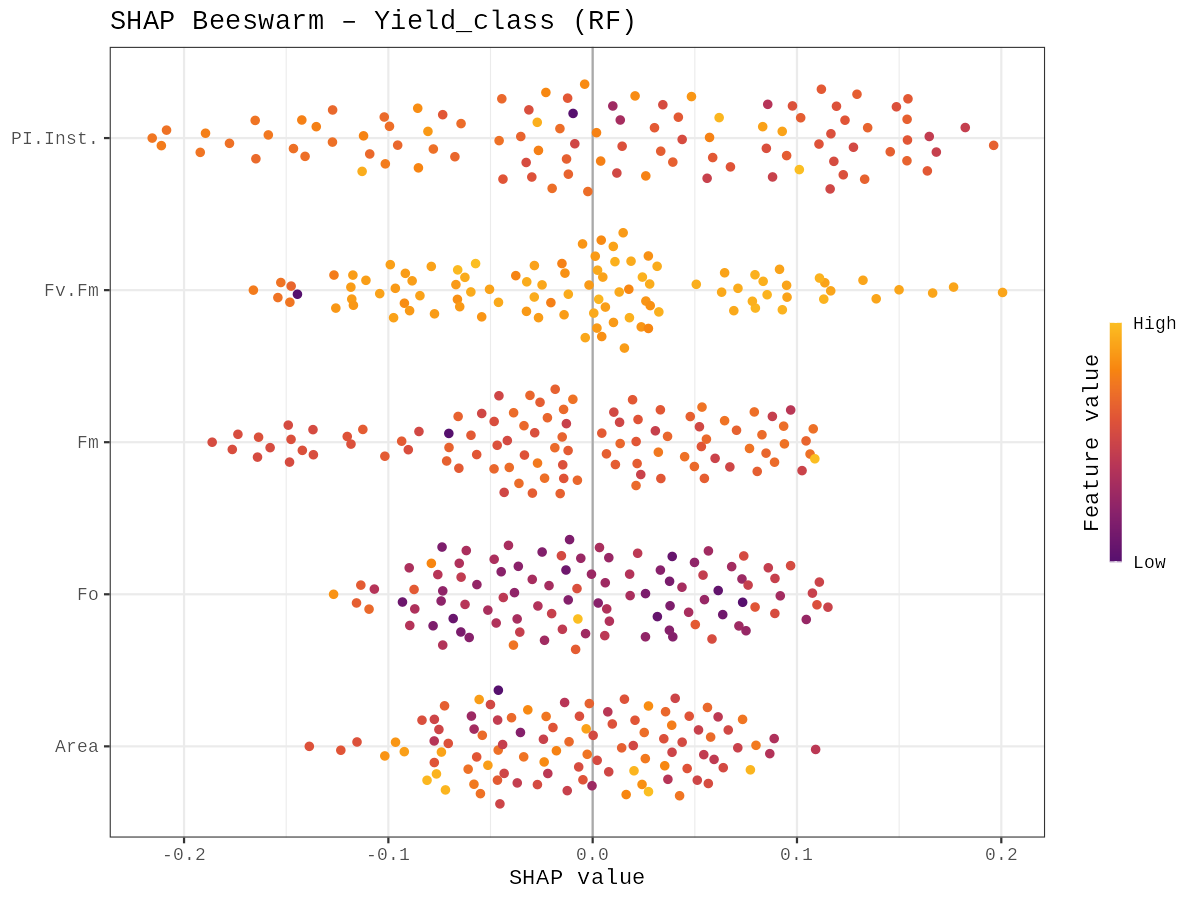

In [ ]:
shap_r = r"""suppressMessages({
  library(tidyverse); library(caret); library(randomForest)
  library(nnet); library(kernelshap); library(shapviz)
})

# Re-derive merged data and the seeded split exactly as the author does
features <- read_delim("feature_data.txt", delim = "\t", skip = 13, trim_ws = TRUE)
names(features) <- make.names(names(features))
target <- read_delim("target_variables.txt", delim = "\t", trim_ws = TRUE)
features$Record.No <- as.character(features$Record.No)
target$PlotID <- as.character(target$PlotID)
merged_full <- left_join(target, features, by = c("PlotID" = "Record.No"))
merged_line <- merged_full %>%
  group_by(LineID) %>%
  summarise(across(where(is.numeric), ~ median(.x, na.rm = TRUE)), .groups = "drop")
meta_cols <- merged_full %>%
  select(LineID, starts_with("Genotype"), starts_with("Variety")) %>%
  distinct(LineID, .keep_all = TRUE)
merged <- left_join(meta_cols, merged_line, by = "LineID")
to_binary <- function(x) {
  med <- median(x, na.rm = TRUE)
  factor(ifelse(x > med, "High", "Low"), levels = c("Low","High"))
}
merged <- merged %>% mutate(Yield_class = to_binary(`Yield_kg_per_plot`))
X <- merged %>% select(Area, Fo, Fm, Fv.Fm, PI.Inst.)

df <- cbind(Target = merged[["Yield_class"]], X)
df <- df[complete.cases(df), ]
df$Target <- factor(df$Target, levels = c("Low","High"))
idx <- createDataPartition(df$Target, p = 0.8, list = FALSE)
train_df <- df[idx, ]
test_df  <- df[-idx, ]

pred_fun <- function(model, X) {
  as.numeric(predict(model, newdata = as.data.frame(X), type = "prob")[, "High"])
}

model_source <- "committed saved_models/model_Yield_class_rf.rds"
rf_model <- readRDS("saved_models/model_Yield_class_rf.rds")
probe <- tryCatch({pred_fun(rf_model, head(train_df[,-1], 2)); TRUE},
                  error = function(e) {
                    cat("NOTE: committed .rds incompatible with this caret version (",
                        conditionMessage(e), ")\n")
                    FALSE })
if (!probe) {
  model_source <- "retrained_models/model_Yield_class_rf.rds (this runtime)"
  rf_model <- readRDS(model_source)
}
cat("SHAP model:", model_source, "\n")
print(caret::getModelInfo(rf_model$method)$rf$label)

set.seed(123)
expl <- kernelshap(
  rf_model,
  X = train_df[1:100, -1],
  bg_X = test_df[1:100, -1],
  pred_fun = pred_fun
)
sv <- shapviz(expl, X_pred = train_df[1:100, -1])

p1 <- sv_importance(sv, kind = "bar") +
  ggtitle("SHAP Global Importance \u2013 Yield_class (RF)") + theme_bw()
p2 <- sv_importance(sv, kind = "beeswarm") +
  ggtitle("SHAP Beeswarm \u2013 Yield_class (RF)") + theme_bw()
ggsave("SHAP_Global_Importance_Yield_RF.png", p1, width = 8, height = 6, dpi = 150)
ggsave("SHAP_Beeswarm_Yield_RF.png", p2, width = 8, height = 6, dpi = 150)
cat("SHAP plots written\n")
print(as.data.frame(expl$S))
"""
(CONTENT / "shap_colab.R").write_text(shap_r)
import time
t0 = time.time()
r = subprocess.run([RSCRIPT, "shap_colab.R"], cwd="/content", timeout=3600,
                   capture_output=True, text=True)
print(r.stdout[-4000:])
if r.stderr:
    print(r.stderr[-2000:])
print(f"[R SHAP exit {r.returncode}] {time.time()-t0:.0f} s")
assert r.returncode == 0, f"SHAP step failed:\n{r.stderr[-2000:]}"
from IPython.display import Image, display
display(Image(filename=str(CONTENT / "SHAP_Global_Importance_Yield_RF.png")))
display(Image(filename=str(CONTENT / "SHAP_Beeswarm_Yield_RF.png")))

## Interpretation, differences, and validation record

**What was executed (validated on 2026-10-05, free-tier Colab CPU runtime):**
the author's exact `YieldLearn.R` pipeline (commit `e519c7b`) for `Yield_class` —
data merge/median-aggregation, median-split labels, five caret classifiers with
the author's grids, seed 123, 5-fold CV, center/scale preprocessing — plus the
SHAP analysis of the committed saved random forest via `kernelshap`/`shapviz`.
All results above (performance table, ROC curves, SHAP plots) are actual outputs
of this notebook; the delivered version embeds the CPU-run outputs.

**Reading the results** (author README §6-8): with only ~165 field plots and five
correlated fluorescence parameters, accuracies near 0.55–0.60 and AUCs near 0.5–0.6
are expected — the paper itself frames YieldLearn as an exploratory pipeline,
not a production predictor. SHAP direction (per the paper): higher `Fv/Fm` and
`PI Inst.` push predictions toward High yield, while elevated `Fo` indicates
stress; `Fm` often dominates due to its wider dynamic range.

**Differences from the paper / scope omitted** (all documented above):
- Only `Yield_class` is trained (the paper's shipped model; other trait models
  are not in the repository's `saved_models/`).
- Per-trait batch loop, JPG summary figures, and the Shiny app UI are omitted;
  the SHAP section follows the author's own code path (`YieldLearn.R:298-335`).
- `doParallel` is not used (≈165-row data; the author commented out its
  shutdown already).

**Known limitations:** no LICENSE file exists in the repository although the
README claims MIT — reuse/ redistribution of the author's code or data requires
operator verification. The committed `.rds` was validated for byte identity
(git blob SHA-1) and compatibility on this runtime inside this notebook.
A single-example run does not verify the paper's dataset-level claims.

**References:**
- Zhang, X. (2026). YieldLearn… bioRxiv 2026.09.22.753232, DOI 10.64898/2026.09.22.753232
- Author code: https://github.com/zx0223winner/YieldLearn @ `e519c7b92c048470d1108c9060a5d44ee4aa13f9`
- Kuhn M (2008+) `caret`; Slack et al. `kernelshap`; ModelOriented `shapviz`.

**日本語:** 上記の性能表・ROC・SHAP は本ノートブックの実行結果です。
本デモは `Yield_class` に限定した部分再現であり、データ約165プロットの小規模
例であるため、精度は概ね 0.55〜0.60 程度で、論文自身も探索的パイプラインと
位置づけています。リポジトリに LICENSE ファイルがなく README が MIT を主張
している点は、再配布前に要確認です。